In [3]:
import pandas as pd
import folium
import matplotlib.pyplot as plt

from folium.plugins import HeatMap
from folium.features import DivIcon

In [4]:
# 1) Cargar puestos de votacion como string
path = '../data/ESTADÍSTICAS_DE_LAS_PERSONAS_DESMOVILIZADAS_QUE_HAN_INGRESADO_AL_PROCESO_DE_REINTEGRACIÓN_20260504.csv'
df = pd.read_csv(path, encoding='utf-8', dtype=str)

In [5]:
print(df.size)
print(df.columns)
print(df.head())

2211924
Index(['Tipo de Desmovilización', 'Ex Grupo', 'Año desmovilización',
       'Ingresó/No ingresó', 'Año de Independización/Ingreso', 'Grupo Etario',
       'Sexo', 'Situación Final frente al proceso',
       'Departamento de residencia descripción',
       'Municipio de residencia descripción', 'Departamento de residencia',
       'Municipio de residencia', 'BeneficioTRV', 'BeneficioFA',
       'BeneficioFPT', 'BeneficioPDT', 'Nivel Educativo',
       'Máximo Nivel FpT Reportado', 'Línea de FpT para el Máx. Nivel',
       'OcupacionEconomica', 'Desembolso BIE', 'Tipo de BIE Accedido',
       'DesagregadoDesembolsoBIE', 'Estado ISUN', 'Posee Servicio Social?',
       'Estado de la vinculación ASS', 'Tipo de ASS Vinculada',
       'Posee Censo de Familia?', 'Posee Cónyuge o Compañero(a)?',
       'N° de Hijos', 'Total Integrantes grupo familiar',
       'Posee Censo de Habitabilidad?', 'Tipo de Vivienda',
       'Régimen de tenencia Vivienda', 'Posee Serv. Públicos Básicos',
     

In [6]:
df.rename(columns={'Año desmovilización': 'año'}, inplace=True)
df.rename(columns={'Departamento de residencia descripción': 'departamento'}, inplace=True)

# limpiar la columna año voliendolo str y removiendo . 
df['año'] = df['año'].astype(str).str.replace('.', '')

In [11]:
# Contar por departamento ordenar por cantidad
df.groupby('departamento').size().sort_values(ascending=False)

departamento
Antioquia                                                   12234
Bogotá D.C.                                                  5485
Meta                                                         3394
Córdoba                                                      3241
Cesar                                                        3029
Valle del Cauca                                              2995
<No Registra>                                                2601
Santander                                                    2453
Magdalena                                                    1997
Cundinamarca                                                 1847
Tolima                                                       1408
Atlántico                                                    1393
Norte de Santander                                           1387
Bolívar                                                      1352
Huila                                                        13

In [7]:
# contar cuantos registros hay en el dataset
print(f"Total de registros: {df.shape[0]}")

Total de registros: 56716


In [13]:
df.groupby('año').size().sort_index(ascending=False)

año
2026       18
2025      280
2024      134
2023      103
2022      153
2021      195
2020      203
2019      244
2018      404
2017      811
2016      668
2015      767
2014      962
2013     1059
2012      906
2011     1214
2010     2009
2009     2549
2008     2858
2007     2729
2006    19607
2005    12020
2004     4374
2003     2438
2002        9
2001        2
dtype: int64

<Axes: xlabel='año'>

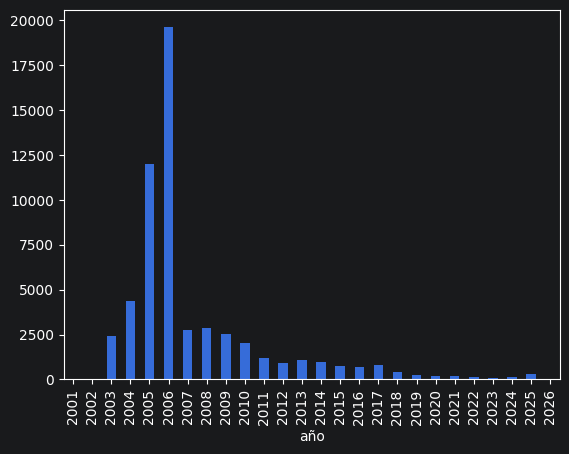

In [14]:
conteo_anio = df.groupby('año').size().sort_index()
conteo_anio.plot(kind='bar', x='año', y='count')


In [28]:
# Contar por EX GRUPO
df.groupby('Ex Grupo').size().sort_index(ascending=False)

Ex Grupo
SIN DATO MINDEFENSA       93
SIN DATO                  74
GAO Residual             195
GAO Pelusos                2
GAO Clan del Golfo        20
GAO Caparros               4
FARC                   17753
ERP                      170
ERG                      140
EPL                      135
ELN                     4776
AUC                    33354
dtype: int64

In [9]:
# Contar por ingreso o no ingreso
df.groupby('Ingresó/No ingresó').size().sort_index(ascending=False)

Ingresó/No ingresó
Sí    54068
No     2648
dtype: int64

In [11]:
# Contar por genero
(df.groupby('Sexo').size()
 .sort_index(ascending=False))

Sexo
Masculino    49123
Femenino      7593
dtype: int64

In [31]:
# Contar por Grupo Etario
(df.groupby('Grupo Etario').size()
 .sort_index(ascending=False))

Grupo Etario
Mayor de 60 años       3305
Entre 41 y 60 años    39815
Entre 26 y 40 años    12705
Entre 18 y 25 años      829
<No Registra>            62
dtype: int64

In [32]:

# Contar por Nivel Educativo
(df.groupby('Nivel Educativo').size()
 .sort_index(ascending=False))

Nivel Educativo
Por Establecer       11104
Básica Secundaria     8448
Básica Primaria      14970
Bachiller            18210
Alfabetización        3984
dtype: int64

In [33]:

# Contar por OcupacionEconomica
df.groupby('OcupacionEconomica').size().sort_index(ascending=False)

OcupacionEconomica
Población Económicamente Inactiva     6253
Ocupados en el sector Informal       26933
Ocupados en el sector Formal             1
No Aplica                             7597
Desocupados                           4595
<No Registra>                        11337
dtype: int64

In [16]:

# Contar por N# de Posee Serv. Públicos Básicos
df.groupby('Posee Serv. Públicos Básicos').size().sort_index(ascending=False)


Posee Serv. Públicos Básicos
Sí             22710
No             11714
<No Aplica>    22292
dtype: int64

# Filtros y agrupacion por año

In [19]:
df_auc = df[
    (df['Ex Grupo'] == 'AUC')
]
df_auc.groupby('año').size().sort_index(ascending=False)


año
2021        3
2020        2
2016        2
2014        1
2012       29
2011       20
2010       96
2009        8
2008      121
2007       64
2006    17663
2005    10847
2004     3211
2003     1287
dtype: int64

Text(0.5, 1.0, 'Cantidad de desmovilizados por año del Ex Grupo AUC')

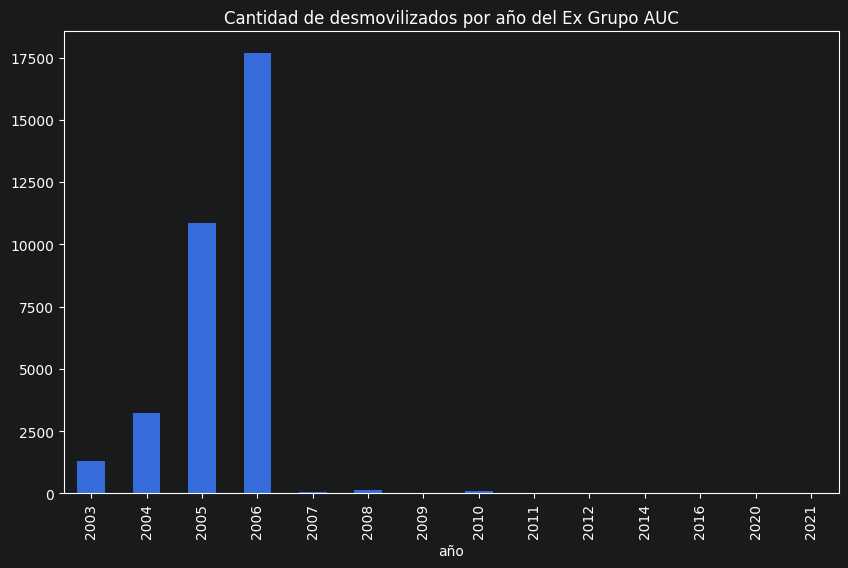

In [23]:
plt.figure(figsize=(10, 6))
df_auc.groupby('año').size().sort_index(ascending=True).plot(kind='bar', x='año', y='count')
plt.title('Cantidad de desmovilizados por año del Ex Grupo AUC')

In [21]:
df_eln = df[
    (df['Ex Grupo'] == 'ELN')
]
df_eln.groupby('año').size().sort_index(ascending=False)


año
2026      4
2025     64
2024     81
2023     53
2022     90
2021    131
2020    173
2019    189
2018    271
2017    272
2016    248
2015    128
2014    125
2013    197
2012    101
2011    158
2010    290
2009    468
2008    299
2007    360
2006    316
2005    251
2004    224
2003    281
2002      2
dtype: int64

Text(0.5, 1.0, 'Cantidad de desmovilizados por año del Ex Grupo ELN')

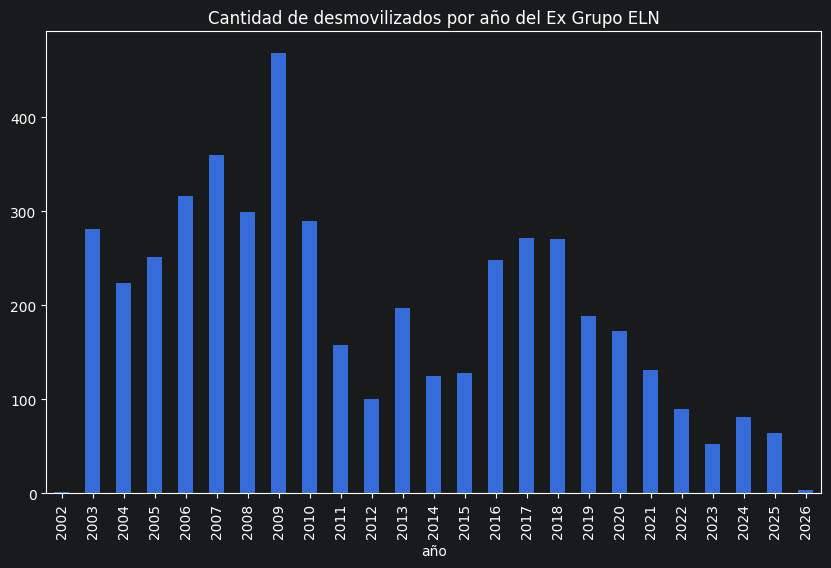

In [24]:
plt.figure(figsize=(10, 6))
df_eln.groupby('año').size().sort_index(ascending=True).plot(kind='bar', x='año', y='count')
plt.title('Cantidad de desmovilizados por año del Ex Grupo ELN')

In [25]:
df_farc = df[
    (df['Ex Grupo'] == 'FARC')
]
df_farc.groupby('año').size().sort_index(ascending=False)

año
2026       6
2025     164
2022       3
2021       7
2019       7
2018      90
2017     511
2016     410
2015     636
2014     834
2013     862
2012     773
2011    1033
2010    1614
2009    2052
2008    2377
2007    2164
2006    1564
2005     896
2004     902
2003     839
2002       7
2001       2
dtype: int64

Text(0.5, 1.0, 'Cantidad de desmovilizados por año del Ex Grupo FARC')

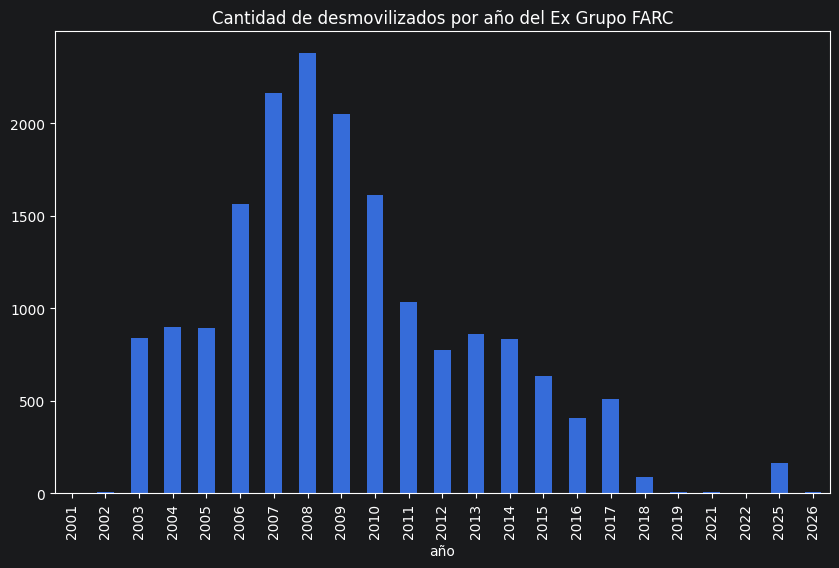

In [26]:
plt.figure(figsize=(10, 6))
df_farc.groupby('año').size().sort_index(ascending=True).plot(kind='bar', x='año', y='count')
plt.title('Cantidad de desmovilizados por año del Ex Grupo FARC')